# Make color-color and color-magnitude diagrams by class

Requires downloading the data from https://zenodo.org/records/10522816, then they need to be extracted into the parent directory of this one (I think)

In [16]:
ls /blue/adamginsburg/richardson.t/research/flux/ccdwork

ccds/                 FitzIndeb_3.1.txt    __init__.py           r06_ccds.ipynb
ccds.ipynb            frac_class_ccds.py   medium_effects.ipynb  stage_ccds.py
class_ccds.py         frac_class_ccds.py~  mixed_class_ccds.py   stage_ccds.py~
class_ccds.py~        frac_stage_ccds.py   mixed_class_ccds.py~  util.py
coldsource.pdf        frac_stage_ccds.py~  mixed_stage_ccds.py   util.py~
confusion_matrix.py   gut_ccds.py          mixed_stage_ccds.py~  westerlund/
confusion_matrix.py~  hotsource.pdf        __pycache__/


In [17]:
cd /blue/adamginsburg/richardson.t/research/flux/ccdwork

/blue/adamginsburg/richardson.t/research/flux/ccdwork


In [18]:
ls

ccds/                 FitzIndeb_3.1.txt    __init__.py           r06_ccds.ipynb
ccds.ipynb            frac_class_ccds.py   medium_effects.ipynb  stage_ccds.py
class_ccds.py         frac_class_ccds.py~  mixed_class_ccds.py   stage_ccds.py~
class_ccds.py~        frac_stage_ccds.py   mixed_class_ccds.py~  util.py
coldsource.pdf        frac_stage_ccds.py~  mixed_stage_ccds.py   util.py~
confusion_matrix.py   gut_ccds.py          mixed_stage_ccds.py~  westerlund/
confusion_matrix.py~  hotsource.pdf        __pycache__/


In [19]:
from sedfitter.sed import SEDCube
from astropy.table import Table
seds =SEDCube.read(f'/blue/adamginsburg/richardson.t/research/flux/r+24_models-1.2.1/s---s-i/flux.fits')
seds.apertures
Table.read('/blue/adamginsburg/richardson.t/research/flux/r+24_models-1.2.1/s---s-i/parameters.fits')

MODEL_NAME,star.radius,star.temperature,scattering,inclination,Source Luminosity,Spectral Index
,,,,,solLum,
bytes20,float64,float64,int64,float64,float64,float64[20]
01QyhoBc_01,0.2728,4888.0,1,45.0,0.03827429493798022,-2.904054707983809 .. -2.904054707983809
01Xx6elC_01,0.383,12050.0,1,45.0,2.7863740310410456,-2.961277104348707 .. -2.961277104348707
03ZZRVTe_01,31.22,4967.0,1,45.0,534.4857312835463,-2.90550368036908 .. -2.90550368036908
03amqKIp_01,13.81,7891.0,1,45.0,666.2070265981496,-2.9305103457753585 .. -2.9305103457753585
03dloFhH_01,44.63,6450.0,1,45.0,3105.8917167595805,-2.922417479172043 .. -2.922417479172043
03jGXYVQ_01,4.797,9889.0,1,45.0,198.26343341171273,-2.941762449378067 .. -2.941762449378067
05DVDxNM_01,0.6069,4998.0,1,45.0,0.20706798645839214,-2.9061117170715924 .. -2.9061117170715924
05qQySTl_01,8.242,7737.0,1,45.0,219.30538007941993,-2.929861779561813 .. -2.929861779561813


  0%|          | 0/18 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

ho ([(2, 0.45), (2, 0.8), (7, 1.6), (7, 1.1)], [(2.2, 0.2), (2.2, 0.35), (7, 0.9), (7, 0.6)])
ho ([(2, 0.45), (2, 0.8), (7, 1.6), (7, 1.1)], [(2.2, 0.2), (2.2, 0.35), (7, 0.9), (7, 0.6)])
ho ([(2, 0.45), (2, 0.8), (7, 1.6), (7, 1.1)], [(2.2, 0.2), (2.2, 0.35), (7, 0.9), (7, 0.6)])
ho ([(2, 0.45), (2, 0.8), (7, 1.6), (7, 1.1)], [(2.2, 0.2), (2.2, 0.35), (7, 0.9), (7, 0.6)])
ho ([(2, 0.45), (2, 0.8), (7, 1.6), (7, 1.1)], [(2.2, 0.2), (2.2, 0.35), (7, 0.9), (7, 0.6)])
ho ([(2, 0.45), (2, 0.8), (7, 1.6), (7, 1.1)], [(2.2, 0.2), (2.2, 0.35), (7, 0.9), (7, 0.6)])
ho ([(2, 0.45), (2, 0.8), (7, 1.6), (7, 1.1)], [(2.2, 0.2), (2.2, 0.35), (7, 0.9), (7, 0.6)])
ho ([(2, 0.45), (2, 0.8), (7, 1.6), (7, 1.1)], [(2.2, 0.2), (2.2, 0.35), (7, 0.9), (7, 0.6)])
ho ([(2, 0.45), (2, 0.8), (7, 1.6), (7, 1.1)], [(2.2, 0.2), (2.2, 0.35), (7, 0.9), (7, 0.6)])
ho ([(2, 0.45), (2, 0.8), (7, 1.6), (7, 1.1)], [(2.2, 0.2), (2.2, 0.35), (7, 0.9), (7, 0.6)])
ho ([(2, 0.45), (2, 0.8), (7, 1.6), (7, 1.1)], [(2.2, 0.2), 

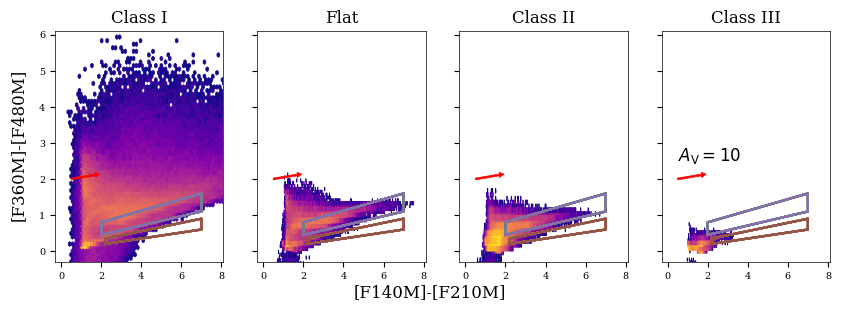

In [20]:
import numpy as np
from astropy.table import Table
from astropy import constants,units as u
import matplotlib.pyplot as plt
from astroquery.svo_fps import SvoFps
from glob import glob
from tqdm.auto import tqdm
from dust_extinction.averages import CT06_MWLoc
from matplotlib.path import Path

def map_to_class(class_indices):
    return -1*(class_indices-3)

def extinct_colordiff(wav1,wav2,Av=10):
    return CT06_MWLoc()(wav1) * Av - CT06_MWLoc()(wav2) * Av

def energy_ok(g,ap_ind,pars):
    seds = SEDCube.read(f'{g}/flux.fits')
    dwav_over_wav = (seds.wav[:-1] - seds.wav[1:]) / ((seds.wav[1:] + seds.wav[:-1])/2)
    dwav_over_wav = dwav_over_wav.mean() # same value throughout b/c geomspaced
    dnu = (dwav_over_wav * seds.wav * constants.c / seds.wav**2).to(u.Hz)
    lum_integrals = (np.nansum(seds.val[:,ap_ind]*dnu, axis=-1) 
                     * 4*np.pi*(1*u.kpc)**2).to(u.L_sun).value
    ok = lum_integrals > 1e-4*pars['Model Luminosity']
    return ok

extinct = Table.read('FitzIndeb_3.1.txt',format='ascii')
'''
cam = 'NIRCam'
filters = SvoFps.get_filter_list(facility='JWST',instrument='NIRCam')
indices = [2,4,4,10]
x = -0.5; y = 2.5; offset = 1
xlim = np.array([-1.9,6.1]); ylim = np.array([-0.9,6.9]) #small apertures
nbins = [1300,300,300,300]
mincnts = [15,5,5,5]
#xlim = np.array([-2.9,9.1]); ylim = np.array([-1.9,9.9]) #big apertures
#nbins = [1000,150,150,350]
#mincnts = [15,5,5,5]
'''
filters = SvoFps.get_filter_list(facility='JWST')
filters.add_index('filterID')

polygons = {
    "".join(['JWST/NIRCam.F140M', 'JWST/NIRCam.F210M', 'JWST/NIRCam.F360M', 'JWST/NIRCam.F480M', ]):
    ([(2,0.45), (2,0.8), (7, 1.6), (7, 1.1)],
     [(2.2,0.2), (2.2,0.35 ), (7,0.9), (7, 0.6)]),
}
#vertices_upper = [(2,0.45), (2,0.8), (7, 1.6), (7, 1.1)]
#vertices_lower = [(2.2,0.2), (2.2,0.35 ), (7,0.9), (7, 0.6)]
basepath = '/blue/adamginsburg/richardson.t/research/flux/r+24_models-1.2.1/'

for filternames in (['JWST/NIRCam.F140M', 'JWST/NIRCam.F210M', 'JWST/NIRCam.F360M', 'JWST/NIRCam.F480M', ],
                    ['JWST/NIRCam.F277W', 'JWST/MIRI.F770W', 'JWST/NIRCam.F277W', 'JWST/MIRI.F1000W'],
                    ['JWST/NIRCam.F150W', 'JWST/MIRI.F770W', 'JWST/MIRI.F770W', 'JWST/MIRI.F1000W'],
                    ['JWST/NIRCam.F200W', 'JWST/NIRCam.F277W', 'JWST/NIRCam.F200W', 'JWST/MIRI.F770W'],):
    #indices = [0,2,2,10]
    #x = 1; y = 5; offset = 0.5
    #xlim = np.array([-0.3,10.1])
    #ylim = np.array([-0.3,7.1])
    #indices = [0,1,1,7]
    x = 0.5; y = 2; offset = 0.5
    xlim = np.array([-0.3,8.1]); ylim = np.array([-0.3,6.1]) #small apertures
    nbins = [1300,800,800,1000]
    mincnts = [15,5,5,5]
    #xlim = np.array([-3.1,11.1]); ylim = np.array([-3.1,9.1]) #big apertures
    #nbins = [1000,450,450,600]
    #mincnts = [15,3,3,3]
    #'''
    
    names = filters.loc[filternames]['filterID']
    insts = [n.split('/')[1].split('.')[1] for n in names]
    wavelengths = filters.loc[filternames]['WavelengthRef']
    
    zeropoints = filters.loc[filternames]['ZeroPoint']*1000
    colors = [(names[0],names[1]),(names[2],names[3])]
    combos = [(colors[0],colors[1])]
    exts = [extinct_colordiff(wavelengths.quantity[0],wavelengths.quantity[1]),
            extinct_colordiff(wavelengths.quantity[2],wavelengths.quantity[3])]
    
    all_gs = glob('../r+24_models-1.2.1/s*')
    ap_ind = 3
    
    #assign classes based on spectral index
    class_dict = {}
    classpoints = np.array([-1.6,-0.3,0.3,np.inf])
    for g in tqdm(all_gs):
        geo = g.split('/')[-1]
        indices = Table.read(f'../spectral_indices/{geo}.fits')
        obs_class = np.searchsorted(classpoints,indices['Spectral Index'][:,ap_ind],side='right')
        obs_class = map_to_class(np.array(obs_class))
        class_dict.update({g:obs_class})


    matched_indexes_upper = {}
    matched_indexes_lower = {}
    fnstr = "".join(filternames)

    
    class_names = ['Class I','Flat','Class II','Class III']
    fig, ax = plt.subplots(1,len(class_names),figsize=(10,3),sharex=True,sharey=True)
    for i in tqdm(range(len(class_names))):
        c1 = []; c2 = []
        for g in (all_gs):
            matched_indexes_upper[g] = []
            matched_indexes_lower[g] = []
            class_cut = class_dict[g] == i
            for ii, (color1,color2) in enumerate(combos):
                tbs = {cname:Table.read(f'{g}/convolved/{cname}.fits')
                       for cname in color1 + color2}
                keys1 = [col for col in color1]
                keys2 = [col for col in color2]
    
                colorp1 = -2.5*np.log10(tbs[keys1[0]]['TOTAL_FLUX'][class_cut, ap_ind]/zeropoints[ii]) + 2.5*np.log10(tbs[keys1[1]]['TOTAL_FLUX'][class_cut, ap_ind]/zeropoints[ii+1]) + extinct_colordiff(wavelengths.quantity[ii], wavelengths.quantity[ii+1], Av=10)
                colorp2 = -2.5*np.log10(tbs[keys2[0]]['TOTAL_FLUX'][class_cut, ap_ind]/zeropoints[ii+2]) + 2.5*np.log10(tbs[keys2[1]]['TOTAL_FLUX'][class_cut, ap_ind]/zeropoints[ii+3]) + extinct_colordiff(wavelengths.quantity[ii+2], wavelengths.quantity[ii+3], Av=10)
            
                c1.extend(colorp1); c2.extend(colorp2)
                
                if fnstr in polygons:
                    
                    for pg in polygons[fnstr]:
                        xx, yy = zip(*pg)
                        xx = xx + (xx[0],)
                        yy = yy + (yy[0],)
                        vertices = np.array(list(zip(xx, yy)))
                        ax[i].plot(xx, yy)
                    ptbl = Table.read(f'{basepath}/{g}/parameters.fits')
                    print('ho', polygons[fnstr])
                    path_upper = Path(polygons[fnstr][0])
                    path_lower = Path(polygons[fnstr][1])
                    if len(colorp1) > 0:
                        incl_upper = path_upper.contains_points(list(zip(colorp1, colorp2)))
                        incl_lower = path_lower.contains_points(list(zip(colorp1, colorp2)))
                    
                        matched_indexes_upper[g].extend(ptbl['MODEL_NAME'][class_cut][incl_upper])
                        matched_indexes_lower[g].extend(ptbl['MODEL_NAME'][class_cut][incl_lower])
                        #print(g, incl.sum())
    
        c1,c2 = np.array(c1),np.array(c2)
        toplot = np.logical_and(np.isfinite(c1),np.isfinite(c2))
        c1,c2 = c1[toplot],c2[toplot]
        ax[i].hexbin(c1,c2,gridsize=nbins[i],mincnt=mincnts[i],
                         bins='log',cmap='plasma')
        ax[i].set_title(class_names[i],fontsize='large')

    
    width = 0.05
    color = 'r'
    
    ax[0].set_xlim(xlim)
    ax[0].set_ylim(ylim)
    
    ax[0].arrow(x,y,*exts,width=width,color=color)
    ax[1].arrow(x,y,*exts,width=width,color=color)
    ax[2].arrow(x,y,*exts,width=width,color=color)
    ax[3].arrow(x,y,*exts,width=width,color=color)
    ax[3].text(x,y+offset,r'$A_{\rm V} = 10$',fontsize='large')
    
    fig.supxlabel(f'[{insts[0]}]-[{insts[1]}]',y=-0.02,fontsize='large')
    fig.supylabel(f'[{insts[2]}]-[{insts[3]}]',x=0.08,fontsize='large')
    
    name = "-".join([x.split(".")[-1] for x in filternames])
    
    #plt.savefig(f'/orange/adamginsburg/robitaille_models/modelgrids/ccds/hexbin_{name}_class_ccd.pdf',dpi=300,bbox_inches='tight')
    break

18
18
{'../r+24_models-1.2.1/s-ubhmi': [], '../r+24_models-1.2.1/s-ubsmi': [], '../r+24_models-1.2.1/sp--s-i': ['7CvNDz0E_04', '7CvNDz0E_05', '7CvNDz0E_06', '9OMN3bQH_07', 'b8lwhpg0_08', 'b8lwhpg0_09', 'CT6hwTH8_09', 'e6fufeSj_07', 'ESydIoGl_09', 'IDIbNnSg_03', 'IDIbNnSg_04', 'IDIbNnSg_05', 'IDIbNnSg_06', 'IDIbNnSg_07', 'IDIbNnSg_08', 'IDIbNnSg_09', 'kiQy0la0_02', 'kiQy0la0_03', 'kiQy0la0_04', 'kiQy0la0_05', 'kiQy0la0_06', 'kiQy0la0_07', 'kiQy0la0_08', 'kiQy0la0_09', 'KPPZjQ3Q_09', 'KTcfv7oT_09', 'lLEhrefB_07', 'lLEhrefB_08', 'lLEhrefB_09', 'nAVidhXy_08', 'NqTFgOm7_09', 'NzEgqPTD_07', 'P9gtzYQB_01', 'P9gtzYQB_02', 'QmWltqi8_09', 'Qr8fGU1W_01', 'Qr8fGU1W_02', 'Qr8fGU1W_03', 'Qr8fGU1W_04', 'Qr8fGU1W_05', 'Qr8fGU1W_06', 'Qr8fGU1W_07', 'Qr8fGU1W_08', 'riYvh8VF_07', 'rrYZUX1j_01', 'rrYZUX1j_02', 'rrYZUX1j_03', 'tJqsmaX6_09', 'Uq2AFOcW_07', 'Y2QFZkkC_09'], '../r+24_models-1.2.1/s-u-hmi': [], '../r+24_models-1.2.1/spubhmi': ['1kGI9aos_01', '1kGI9aos_02', '1kGI9aos_03', '1kGI9aos_04', '1kGI9ao

Text(0.5, 1.0, 'Lower Polygon Matches')

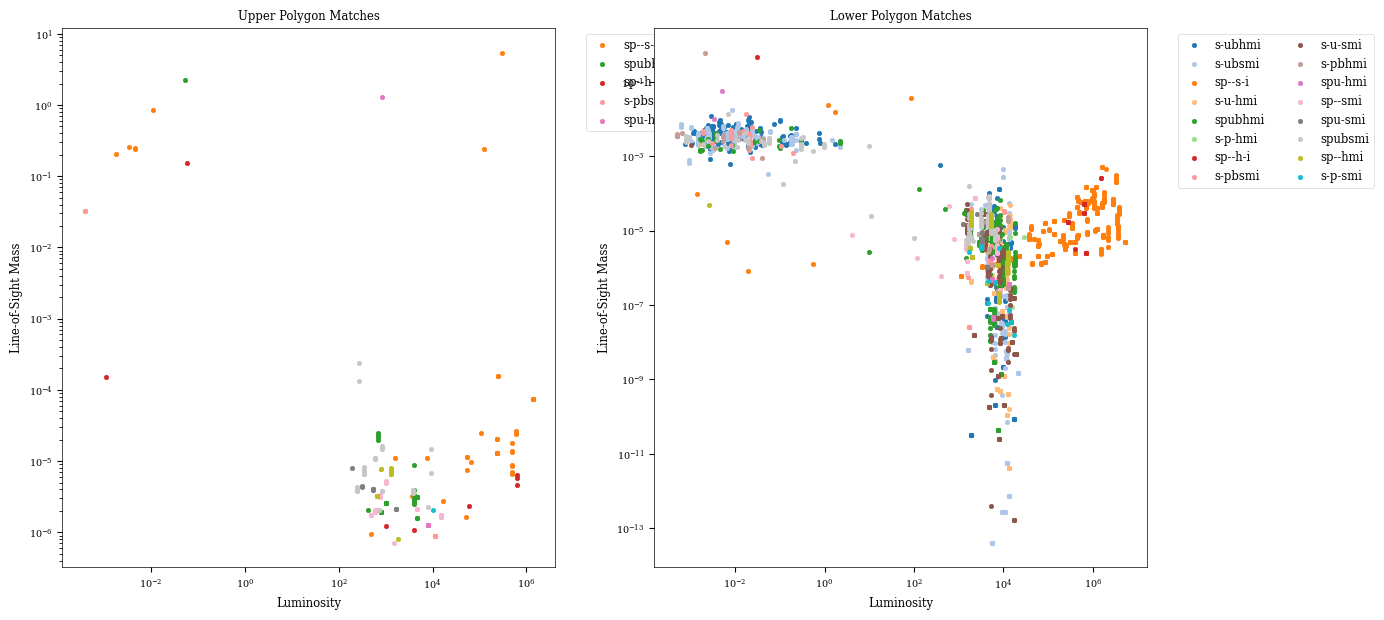

In [21]:
fig = plt.figure(figsize=(14,7))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)
print(len(matched_indexes_upper))
print(len(matched_indexes_lower))
cmap = plt.get_cmap('tab20')
axlist = [ax1, ax2]
matched_indexes = [matched_indexes_upper, matched_indexes_lower]
print(matched_indexes_upper)
print(matched_indexes_lower)
for ax, matched_index in zip(axlist, matched_indexes):
    print(matched_index)
    for ii, geo in enumerate(all_gs):
        ptbl = Table.read(f'/blue/adamginsburg/richardson.t/research/flux/r+24_models-1.2.1/{geo.split("/")[-1]}/parameters.fits')
        ptbl.add_index('MODEL_NAME')
        ttt = ptbl.loc[matched_index[f'{geo}']]
        if len(ttt) == 0:
            continue
        try:
            ax.scatter(ttt['Source Luminosity'], ttt['Line-of-Sight Masses'][:, 3], color=cmap(ii / len(all_gs)), label=geo.split('/')[-1], s=10 )
        except Exception as e:
            print(f'{geo} has no matches')
            print(e)
    ax.set_xlabel('Luminosity')
    ax.set_ylabel('Line-of-Sight Mass')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.legend(fontsize='small', ncol=2, bbox_to_anchor=(1.05, 1))
ax1.set_title('Upper Polygon Matches')
ax2.set_title('Lower Polygon Matches')

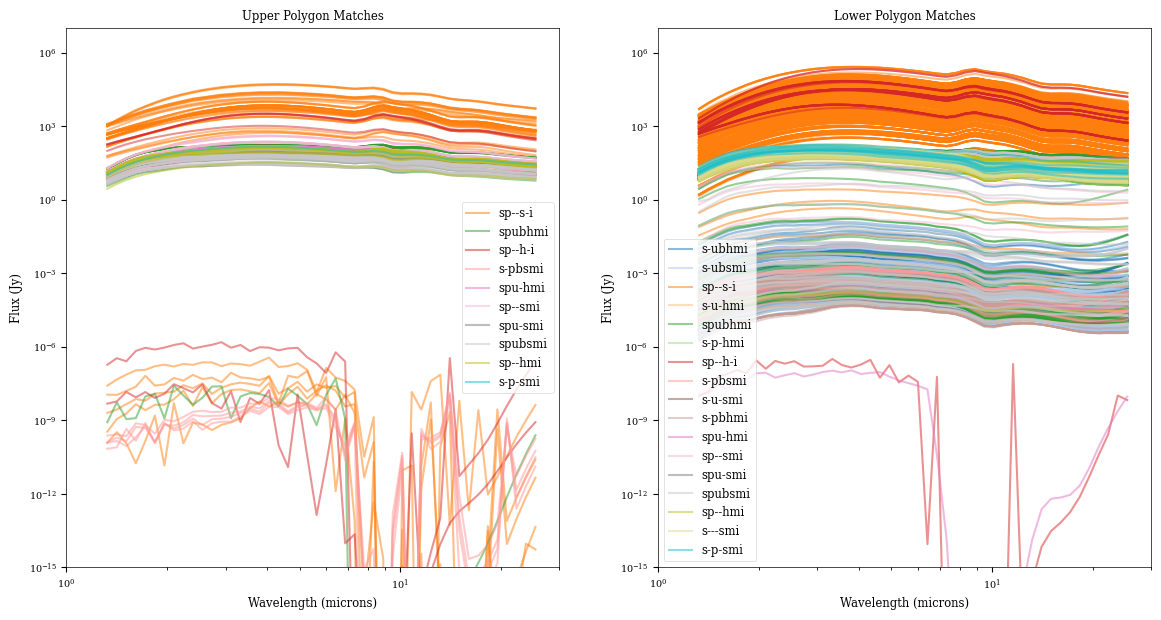

In [22]:
fit = plt.figure(figsize=(14,7))
ax1 = fit.add_subplot(121)
ax2 = fit.add_subplot(122)
axlist = [ax1, ax2]
cmap = plt.get_cmap('tab20')
for ax, matched_index in zip(axlist, matched_indexes):

    for ii, geo in enumerate(all_gs):
        seds = SEDCube.read(f'/blue/adamginsburg/richardson.t/research/flux/r+24_models-1.2.1/{geo.split("/")[-1]}/flux.fits')

        
        match = np.isin(seds.names, matched_index[geo])

        vals = seds.val[match, 3]   # shape: (n_match, n_wav)
        if vals.shape[0] == 0:
            continue
        wav_verified_idx = np.where((seds.wav.value > 1.25) & (seds.wav.value < 27))[0]
        for jj, val in enumerate(vals):
            if jj == 0:
                ax.plot(seds.wav[wav_verified_idx] , val[wav_verified_idx]/5.4**2 * 10**(-CT06_MWLoc()(1/seds.wav[wav_verified_idx]) * 10 / 2.5) , label=geo.split("/")[-1], color=cmap(ii / len(all_gs)), alpha=0.5)
            else:
                ax.plot(seds.wav[wav_verified_idx], val[wav_verified_idx]/5.4**2 * 10**(-CT06_MWLoc()(1/seds.wav[wav_verified_idx]) * 10 / 2.5), color=cmap(ii / len(all_gs)), alpha=0.5)

    ax.loglog()
    ax.set_xlim(1, 30)
    ax.set_ylim(1e-15,1e7)
    ax.legend(fontsize='small')
    ax.set_xlabel('Wavelength (microns)')
    ax.set_ylabel('Flux (Jy)')
    ax1.set_title('Upper Polygon Matches')
    ax2.set_title('Lower Polygon Matches')

In [23]:
seds.wav

<Quantity [4.83863172e+03, 4.53135115e+03, 4.24358464e+03, 3.97409293e+03,
           3.72171547e+03, 3.48536542e+03, 3.26402494e+03, 3.05674083e+03,
           2.86262044e+03, 2.68082780e+03, 2.51058002e+03, 2.35114394e+03,
           2.20183296e+03, 2.06200407e+03, 1.93105511e+03, 1.80842215e+03,
           1.69357708e+03, 1.58602533e+03, 1.48530372e+03, 1.39097850e+03,
           1.30264347e+03, 1.21991822e+03, 1.14244649e+03, 1.06989465e+03,
           1.00195027e+03, 9.38320744e+02, 8.78732052e+02, 8.22927580e+02,
           7.70667009e+02, 7.21725280e+02, 6.75891629e+02, 6.32968675e+02,
           5.92771572e+02, 5.55127213e+02, 5.19873485e+02, 4.86858568e+02,
           4.55940286e+02, 4.26985491e+02, 3.99869489e+02, 3.74475507e+02,
           3.50694187e+02, 3.28423116e+02, 3.07566384e+02, 2.88034174e+02,
           2.69742369e+02, 2.52612198e+02, 2.36569890e+02, 2.21546359e+02,
           2.07476908e+02, 1.94300947e+02, 1.81961734e+02, 1.70406131e+02,
           1.59584375e+02

In [24]:
wavelengths.quantity.to(u.um)

<Quantity [1.40532325, 2.09545131, 3.62417609, 4.81819459] um>

In [25]:
exts

[1.1962701078630593, 0.11210227501965564]

In [26]:
tbs['JWST/NIRCam.F140M']

MODEL_NAME,TOTAL_FLUX,TOTAL_FLUX_ERR
,mJy,mJy
bytes30,float64[20],float64[20]
012vyWLZ_01,0.0 .. 0.0,0.0 .. 0.0
01NLsAxo_01,0.0 .. 0.0,0.0 .. 0.0
01NcC57M_01,3.7164483046581154e-07 .. 9.509073606750462e-06,3.693534154081135e-07 .. 6.728320840920787e-06
0253kK1Q_01,1046.665283203125 .. 2234.980224609375,14.0448579788208 .. 18.811790466308594
02jjDmgA_01,1.314065933227539 .. 1.3312915563583374,0.01871761865913868 .. 0.018718475475907326
02wfju3U_01,0.0 .. 0.0,0.0 .. 0.0
03Izsw7d_01,0.0 .. 2029.47412109375,0.0 .. 222.7660369873047
03W416Iy_01,45.04400634765625 .. 57.20798110961914,0.39571070671081543 .. 0.5190118551254272


['skycoord_ref', 'skycoord_ref_filtername', 'sep_f140m', 'id_f140m', 'skycoord_f140m', 'flux_fit_f140m', 'flux_err_f140m', 'mask_f140m', 'qfit_f140m', 'cfit_f140m', 'local_bkg_f140m', 'roundness1_f140m', 'roundness2_f140m', 'sharpness_f140m', 'from_sat_catalog_f140m', 'std_ra_f140m', 'std_dec_f140m', 'nmatch_f140m', 'nmatch_good_f140m', 'flux_err_prop_f140m', 'sep_f162m', 'id_f162m', 'skycoord_f162m', 'flux_fit_f162m', 'flux_err_f162m', 'mask_f162m', 'qfit_f162m', 'cfit_f162m', 'local_bkg_f162m', 'roundness1_f162m', 'roundness2_f162m', 'sharpness_f162m', 'from_sat_catalog_f162m', 'std_ra_f162m', 'std_dec_f162m', 'nmatch_f162m', 'nmatch_good_f162m', 'flux_err_prop_f162m', 'sep_f182m', 'id_f182m', 'skycoord_f182m', 'flux_fit_f182m', 'flux_err_f182m', 'mask_f182m', 'qfit_f182m', 'cfit_f182m', 'local_bkg_f182m', 'roundness1_f182m', 'roundness2_f182m', 'sharpness_f182m', 'from_sat_catalog_f182m', 'std_ra_f182m', 'std_dec_f182m', 'nmatch_f182m', 'nmatch_good_f182m', 'flux_err_prop_f182m', 's

Set DATE-AVG to '2025-05-06T16:59:22.406' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-05-06T14:19:06.870' from MJD-AVG.
Set DATE-END to '2025-05-06T14:41:02.194' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.220336 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610512569.543 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-05-06T15:11:59.611' from MJD-AVG.
Set DATE-END to '2025-05-06T15:35:36.878' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.237189 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610816321.821 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-05-06T16:06:02.819' from MJD-AVG.
Set DATE-END to '2025-05-06T16:29:39.435' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.254571 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611129611.449 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE

3.053877779107583e-10 deg2
3.0536898714608487e-10 deg2
3.056563930691893e-10 deg2
3.0541063885182936e-10 deg2
3.054668262896466e-10 deg2
9.491459138193236e-10 deg2
9.491459138193236e-10 deg2


Set DATE-AVG to '2025-05-06T13:24:26.757' from MJD-AVG.
Set DATE-END to '2025-05-06T13:48:04.021' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.202550 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610191894.941 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-05-06T16:06:02.828' from MJD-AVG.
Set DATE-END to '2025-05-06T16:29:39.435' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.254571 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611129611.449 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-05-06T16:59:22.421' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2024-09-08T11:22:58.102' from MJD-AVG.
Set DATE-END to '2024-09-08T12:35:44.015' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    -3.810003 from OBSGEO-[XYZ].
Set OBSGEO-H to 1291940033.618 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE

9.49145905084584e-10 deg2
9.491458943030916e-10 deg2
9.49145885655769e-10 deg2
9.491458757317268e-10 deg2
7.524574264515582e-11 deg2


Set DATE-AVG to '2024-09-08T11:47:44.336' from MJD-AVG.
Set DATE-END to '2024-09-08T13:00:37.070' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    -3.791203 from OBSGEO-[XYZ].
Set OBSGEO-H to 1291801554.144 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2024-09-08T11:55:48.768' from MJD-AVG.
Set DATE-END to '2024-09-08T13:08:42.701' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    -3.785099 from OBSGEO-[XYZ].
Set OBSGEO-H to 1291756623.231 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-05-06T13:24:26.762' from MJD-AVG.
Set DATE-END to '2025-05-06T13:48:04.085' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.202551 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610191901.140 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-05-06T16:59:22.406' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE

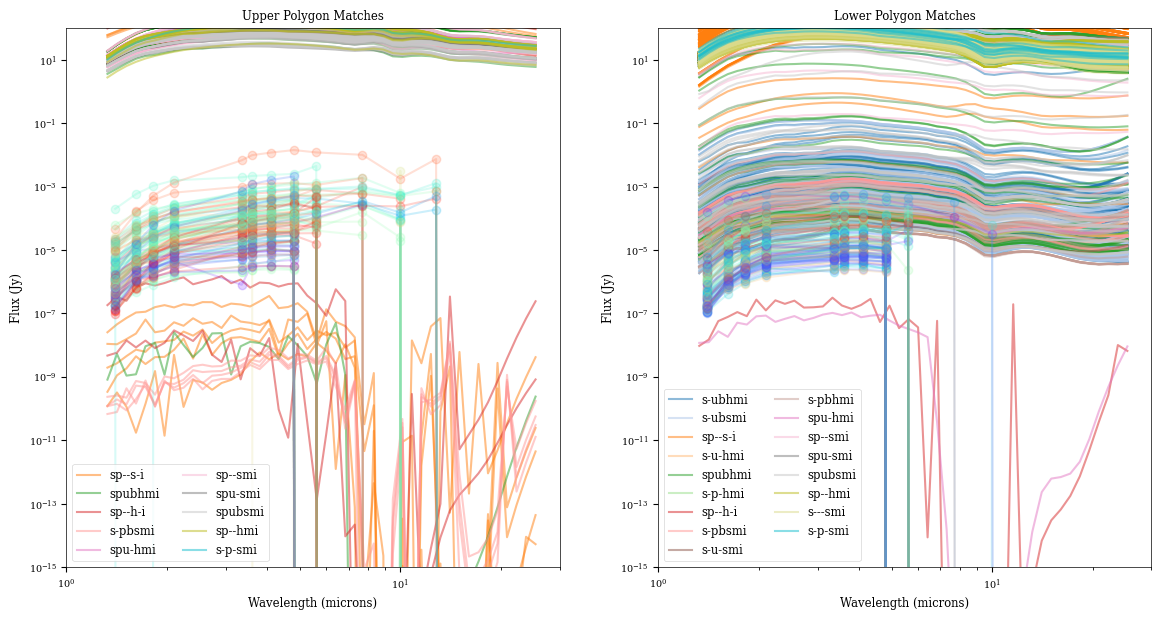

In [29]:
import os
os.environ["CRDS_PATH"] = os.path.expanduser("~/crds_cache")
os.makedirs(os.environ["CRDS_PATH"], exist_ok=True)

os.environ["CRDS_SERVER_URL"] = "https://jwst-crds.stsci.edu"
os.environ["CRDS_CONTEXT"] = "jwst_1460.pmap"

from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astroquery.svo_fps import SvoFps
from astropy.wcs import WCS
from astropy.io import fits
from dust_extinction.averages import RL85_MWGC, CT06_MWLoc
from dust_extinction.parameter_averages import CCM89
import warnings
from astropy.wcs import FITSFixedWarning, WCS


def get_mag(catalog, ww, filtername='f140m' ):
    print(ww.proj_plane_pixel_area())
    
    flux= (catalog['flux_fit_' + filtername] * u.MJy/u.sr * ww.proj_plane_pixel_area()).to(u.Jy)
    eflux_jy = (catalog['flux_err_' + filtername] * u.MJy/u.sr *  ww.proj_plane_pixel_area()).to(u.Jy)

    jfilts = SvoFps.get_filter_list('JWST')
    jfilts.add_index('filterID')
    wav = int(filtername[1:-1])

    zeropoint_ab = 3631 * u.Jy  # Default to AB magnitude zero point
 
    if wav < 500:

        zeropoint_vega = u.Quantity(jfilts.loc[f'JWST/NIRCam.{filtername.upper()}']['ZeroPoint'], u.Jy)
    else:
        zeropoint_vega = u.Quantity(jfilts.loc[f'JWST/MIRI.{filtername.upper()}']['ZeroPoint'], u.Jy)
   
    abmag = -2.5 * np.log10(flux / zeropoint_ab) * u.mag
    abmag_err = 2.5 / np.log(10) * np.abs(eflux_jy / flux) * u.mag

    vegamag = -2.5 * np.log10(flux / zeropoint_vega) * u.mag
    vegamag_err = 2.5 / np.log(10) * np.abs(eflux_jy / flux) * u.mag

    return  vegamag, vegamag_err, abmag, abmag_err



catalog = Table.read('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/final_catalog_refined.fits')
print(catalog.colnames)
image_filenames ={
    "f140m": "/orange/adamginsburg/jwst/w51/F140M/pipeline/jw06151-o001_t001_nircam_clear-f140m-merged_i2d.fits",
    "f150w": "/orange/adamginsburg/jwst/w51/F150W/pipeline/jw06151-o001_t001_nircam_clear-f150w-merged_i2d.fits",
    "f162m": "/orange/adamginsburg/jwst/w51/F162M/pipeline/jw06151-o001_t001_nircam_clear-f162m-merged_i2d.fits",
    "f182m": "/orange/adamginsburg/jwst/w51/F182M/pipeline/jw06151-o001_t001_nircam_clear-f182m-merged_i2d.fits",
    "f187n": "/orange/adamginsburg/jwst/w51/F187N/pipeline/jw06151-o001_t001_nircam_clear-f187n-merged_i2d.fits",
    "f210m": "/orange/adamginsburg/jwst/w51/F210M/pipeline/jw06151-o001_t001_nircam_clear-f210m-merged_i2d.fits",
    "f335m": "/orange/adamginsburg/jwst/w51/F335M/pipeline/jw06151-o001_t001_nircam_clear-f335m-merged_i2d.fits",
    "f360m": "/orange/adamginsburg/jwst/w51/F360M/pipeline/jw06151-o001_t001_nircam_clear-f360m-merged_i2d.fits",
    "f405n": "/orange/adamginsburg/jwst/w51/F405N/pipeline/jw06151-o001_t001_nircam_clear-f405n-merged_i2d.fits",
    "f410m": "/orange/adamginsburg/jwst/w51/F410M/pipeline/jw06151-o001_t001_nircam_clear-f410m-merged_i2d.fits", # weird, the filename is different from what is downloaded with the STScI pipeline...
    "f480m": "/orange/adamginsburg/jwst/w51/F480M/pipeline/jw06151-o001_t001_nircam_clear-f480m-merged_i2d.fits",
    "f560w": "/orange/adamginsburg/jwst/w51/F560W/pipeline/jw06151-o002_t001_miri_f560w_i2d.fits",
    "f770w": "/orange/adamginsburg/jwst/w51/F770W/pipeline/jw06151-o002_t001_miri_f770w_i2d.fits",
    "f1000w": "/orange/adamginsburg/jwst/w51/F1000W/pipeline/jw06151-o002_t001_miri_f1000w_i2d.fits",
    "f1280w": "/orange/adamginsburg/jwst/w51/F1280W/pipeline/jw06151-o002_t001_miri_f1280w_i2d.fits",
    "f2100w": "/orange/adamginsburg/jwst/w51/F2100W/pipeline/jw06151-o002_t001_miri_f2100w_i2d.fits",
    
}

f140m_header = fits.getheader(image_filenames['f140m'], ext=('SCI', 1))
f162m_header = fits.getheader(image_filenames['f162m'], ext=('SCI', 1))
f182m_header = fits.getheader(image_filenames['f182m'], ext=('SCI', 1))
f210m_header = fits.getheader(image_filenames['f210m'], ext=('SCI', 1))
f335m_header = fits.getheader(image_filenames['f335m'], ext=('SCI', 1))
f360m_header = fits.getheader(image_filenames['f360m'], ext=('SCI', 1))
f405n_header = fits.getheader(image_filenames['f405n'], ext=('SCI', 1))
f410m_header = fits.getheader(image_filenames['f410m'], ext=('SCI', 1))
f480m_header = fits.getheader(image_filenames['f480m'], ext=('SCI', 1))
f560w_header = fits.getheader(image_filenames['f560w'], ext=('SCI', 1))
f770w_header = fits.getheader(image_filenames['f770w'], ext=('SCI', 1))
f1000w_header = fits.getheader(image_filenames['f1000w'], ext=('SCI', 1))
f1280w_header = fits.getheader(image_filenames['f1280w'], ext=('SCI', 1))
f2100w_header = fits.getheader(image_filenames['f2100w'], ext=('SCI', 1))



f140m_mag = get_mag(catalog, WCS(f140m_header), filtername='f140m')
f162m_mag = get_mag(catalog, WCS(f162m_header), filtername='f162m')
f182m_mag = get_mag(catalog, WCS(f182m_header), filtername='f182m')
f210m_mag = get_mag(catalog, WCS(f210m_header), filtername='f210m')
f335m_mag = get_mag(catalog, WCS(f335m_header), filtername='f335m')
f360m_mag = get_mag(catalog, WCS(f360m_header), filtername='f360m')
f405n_mag = get_mag(catalog, WCS(f405n_header), filtername='f405n')
f410m_mag = get_mag(catalog, WCS(f410m_header), filtername='f410m')
f480m_mag = get_mag(catalog, WCS(f480m_header), filtername='f480m')
with warnings.catch_warnings():
    warnings.simplefilter("ignore", FITSFixedWarning)
    f560w_wcs = WCS(f560w_header)

f560w_mag = get_mag(catalog, f560w_wcs, filtername='f560w')
f560w_mag = get_mag(catalog, WCS(f560w_header), filtername='f560w')
f770w_mag = get_mag(catalog, WCS(f770w_header), filtername='f770w')
f1000w_mag = get_mag(catalog, WCS(f1000w_header), filtername='f1000w')
f1280w_mag = get_mag(catalog, WCS(f1280w_header), filtername='f1280w')
f2100w_mag = get_mag(catalog, WCS(f2100w_header), filtername='f2100w')

f187n_header = fits.getheader(image_filenames['f187n'], ext=('SCI', 1))
f187n_mag = get_mag(catalog, WCS(f187n_header), filtername='f187n')


from dust_extinction.averages import RL85_MWGC, CT06_MWGC
from dust_extinction.parameter_averages import CCM89
import astropy.constants as const

ext = RL85_MWGC()
ext = CT06_MWLoc()
def plot_extvec_cmd(ax, color1, mag1, ext=RL85_MWGC(), extvec_scale=200, start=None,
                    color='y', head_width=0.5, color1_data=None, mag1_data=None, label=None):
    def get_wave(c):
        if c == '410m405': return 4.10*u.um
        if c == '405m410': return 4.05*u.um
        if c == 'Hmag': return 1.634*u.um
        if c == 'Ksmag': return 2.143527*u.um
        return int(c[1:-1])/100*u.um

    w1 = get_wave(color1[0])
    w2 = get_wave(color1[1])
    w3 = get_wave(mag1[0])

    if w1 > w2:
        w1, w2 = w2, w1
        color1 = color1[::-1]
    print(w1,w2,w3)

    # Only plot if all are in valid range
    try:
        e_1 = ext(1/w1) * extvec_scale
        e_2 = ext(1/w2) * extvec_scale
        e_3 = ext(1/w3) * extvec_scale
    except ValueError as e:
        print(f"Extinction vector not plotted: {e}")
        return
    print(w1,w2,w3)
    print(e_1, e_2, e_3)
    if start == None:
        mean_color1 = np.nanmean(color1_data)
        mean_mag1 = np.nanmean(mag1_data)
        std_color1 = np.nanstd(color1_data)
        std_mag1 = np.nanstd(mag1_data)
        if e_1 - e_2 < 0:
            std_color1 *= -1
        
    
        start2 = (mean_color1 + 2*std_color1, mean_mag1 + 2*std_mag1)
    else:
        start2 = start
    
    # Strip units for plotting if present
    if hasattr(start2[0], 'value'):
        start2_x = start2[0].value
        start2_y = start2[1].value
    else:
        start2_x = start2[0]
        start2_y = start2[1]

    ax.annotate(f'$A_V={extvec_scale}$', xy=(start2_x + (e_1 - e_2), start2_y + e_3),
                xytext=(start2_x, start2_y),
                arrowprops=dict(arrowstyle='-|>', color=color,
                                shrinkA=0, shrinkB=0,
                                mutation_scale=20, linewidth=1.5))
    ax.plot([], [], color=color, marker='>', markersize=8,
            label=f'{label}', linestyle='-', linewidth=2)



imgsavedir = '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/plots/cmds/'
filters = {
    'f140m': f140m_mag,
    'f162m': f162m_mag,
    'f182m': f182m_mag,
    'f187n': f187n_mag,
    'f210m': f210m_mag,
    'f335m': f335m_mag,
    'f360m': f360m_mag,
    'f405n': f405n_mag,
    'f410m': f410m_mag,
    'f480m': f480m_mag,
    'f560w': f560w_mag,
    'f770w': f770w_mag,
    'f1000w': f1000w_mag,
    'f1280w': f1280w_mag,
    'f2100w': f2100w_mag,
}
filter_names = list(filters.keys())

color1 = filters['f140m'][0] - filters['f210m'][0]
color2 = filters['f360m'][0] - filters['f480m'][0]


vertices_upper = [(2,0.45), (2,0.9), (6, 1.6), (6, 0.8)]
vertices_lower = [(2,0), (2,0.4 ), (6, 0.8), (6, 0.3)]
#polygon1 = Polygon(vertices_upper, closed=True, fill=False, edgecolor='blue', linewidth=2, label='Group 1')
#polygon2 = Polygon(vertices_lower, closed=True, fill=False, edgecolor='green', linewidth=2, label='Group 2')
#ax.add_patch(polygon1)
#ax.add_patch(polygon2)
path1 = Path(vertices_upper)
idx1 = path1.contains_points(np.array([color1.value, color2.value]).T)

path2 = Path(vertices_lower)
idx2 = path2.contains_points(np.array([color1.value, color2.value]).T)


fit = plt.figure(figsize=(14,7))
ax1 = fit.add_subplot(121)
ax2 = fit.add_subplot(122)
axlist = [ax1, ax2]
cmap = plt.get_cmap('tab20')
for ax, matched_index in zip(axlist, matched_indexes):

    for ii, geo in enumerate(all_gs):
        seds = SEDCube.read(f'/blue/adamginsburg/richardson.t/research/flux/r+24_models-1.2.1/{geo.split("/")[-1]}/flux.fits')

        
        match = np.isin(seds.names, matched_index[geo])

        vals = seds.val[match, 3]   # shape: (n_match, n_wav)
        if vals.shape[0] == 0:
            continue
        wav_verified_idx = np.where((seds.wav.value > 1.25) & (seds.wav.value < 27))[0]
        for jj, val in enumerate(vals):
            if jj == 0:
                ax.plot(seds.wav[wav_verified_idx] , val[wav_verified_idx]/5.4**2 * 10**(-CT06_MWLoc()(1/seds.wav[wav_verified_idx]) * 10 / 2.5) , label=geo.split("/")[-1], color=cmap(ii / len(all_gs)), alpha=0.5)
            else:
                ax.plot(seds.wav[wav_verified_idx], val[wav_verified_idx]/5.4**2 * 10**(-CT06_MWLoc()(1/seds.wav[wav_verified_idx]) * 10 / 2.5), color=cmap(ii / len(all_gs)), alpha=0.5)

    ax.loglog()
    ax.set_xlim(1, 30)
    ax.set_ylim(1e-15,1e2)
    ax.legend(fontsize='small', ncol=2)
    ax.set_xlabel('Wavelength (microns)')
    ax.set_ylabel('Flux (Jy)')
    ax1.set_title('Upper Polygon Matches')
    ax2.set_title('Lower Polygon Matches')


from matplotlib.colors import LogNorm

def plot_SED(ax, catalog, idx_mask):
    filter_names = ['f140m', 'f162m', 'f182m',  'f210m', 'f335m', 'f360m', 'f410m', 'f480m', 'f560w', 'f770w', 'f1000w', 'f1280w', 'f2100w']
    wavelengths = np.array([int(f[1:-1]) / 100 for f in filter_names]) * u.um

    src_idx = np.where(idx_mask)[0]   # convert boolean mask -> integer indices
    # get random 100 indices from src_idx
    if len(src_idx) > 100:
        src_idx = np.random.choice(src_idx, size=100, replace=False)
    # optional color normalization
    
    cmap = plt.get_cmap("rainbow")

    for i in src_idx:
        flux_arr = []
        for filtername in filter_names:
            flux = (
                catalog['flux_fit_' + filtername][i] * u.MJy / u.sr
                * WCS(fits.getheader(image_filenames[filtername], ext=('SCI', 1))).proj_plane_pixel_area()
            ).to(u.Jy)
            flux_arr.append(flux.value)

        ax.plot(wavelengths.value, flux_arr, marker='o', alpha=0.2,
                color=cmap(i/len(catalog)))

   
plot_SED(ax1, catalog, idx1)
plot_SED(ax2, catalog, idx2)

In [28]:
#